# Leaky Dataset Pipeline
Uses the original dataset split as-is (train/valid/test from `data/`).  
This reproduces the inflated benchmark — the baseline to compare against.

## 1. Imports & Config

In [19]:
import os
import re
import time
import copy
import json
import tracemalloc
import timm
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

import onnx
import onnxruntime as ort
from torch.quantization import quantize_dynamic

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR     = Path('/home/adityaraut/Documents/research_paper')
DATA_DIR     = BASE_DIR / 'data'
LEAKY_DIR    = BASE_DIR / 'leaky'

SAVE_DIRS = {
    'mobilenetv4_conv_small': LEAKY_DIR / 'mnv4_small_leaky',
    'convnext_tiny':          LEAKY_DIR / 'convnext_tiny_leaky',
}

# ── Hyperparameters ────────────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4
FREEZE_EPOCHS = 5      # freeze backbone for first N epochs
NUM_CLASSES  = 15
IMG_SIZE     = 224
VARIANT      = 'leaky'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM: 4.0 GB


## 2. Class Name Normalisation

In [20]:
def normalize_class_name(folder_name: str) -> str:
    """Strip split suffixes, lowercase, underscores.
    Handles: 'Aphid', 'aphid_test', 'aphid_valid', 'blast_test_valid'
    """
    name = re.sub(r'_(test_valid|test|valid)$', '', folder_name)
    return name.lower().replace(' ', '_')


def build_class_map(split_dir: Path):
    """Returns (folder→idx dict, idx→canonical_name list)."""
    folders = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    canonical = sorted(set(normalize_class_name(f) for f in folders))
    class_to_idx = {f: canonical.index(normalize_class_name(f)) for f in folders}
    return class_to_idx, canonical


# Build from train (most complete set of class names)
FOLDER_TO_IDX, CLASS_NAMES = build_class_map(DATA_DIR / 'train')
print('Classes:', CLASS_NAMES)
print('Total classes:', len(CLASS_NAMES))

Classes: ['aphid', 'black_rust', 'blast', 'brown_rust', 'common_root_rot', 'fusarium_head_blight', 'healthy', 'leaf_blight', 'mildew', 'mite', 'septoria', 'smut', 'stem_fly', 'tan_spot', 'yellow_rust']
Total classes: 15


## 3. Dataset & Class Distribution

/tmp/ipykernel_10877/563985914.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)


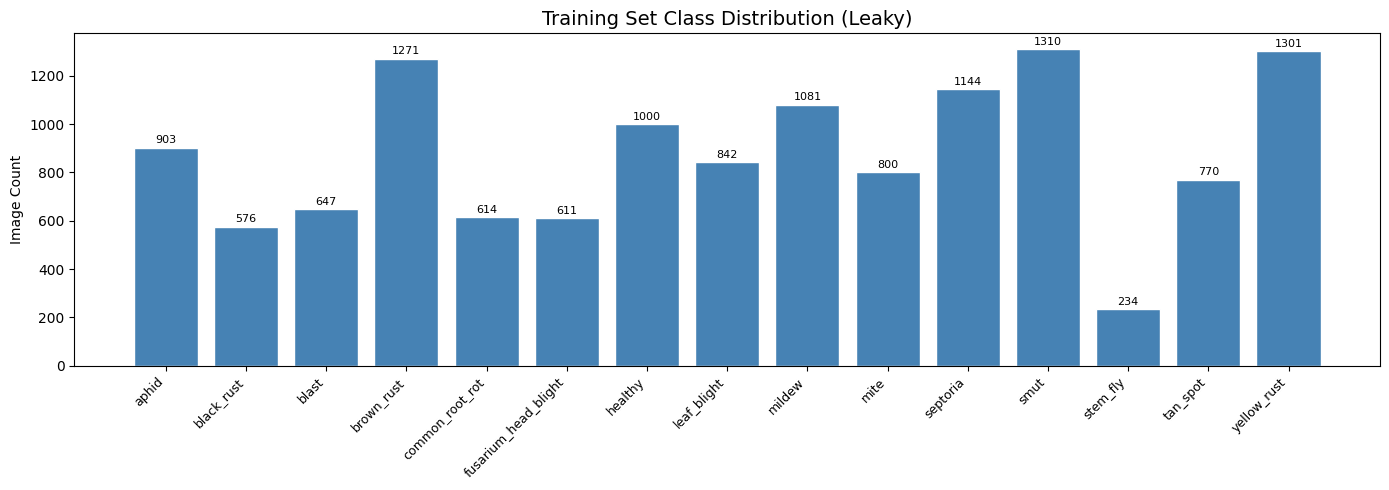

Total train images : 13104
Max class          : smut (1310)
Min class          : stem_fly (234)
Imbalance ratio    : 5.60x


In [21]:
class WheatDiseaseDataset(Dataset):
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

    def __init__(self, split_dir: Path, folder_to_idx: dict, transform=None):
        self.transform = transform
        self.samples   = []   # (path, label_idx)

        for folder, idx in folder_to_idx.items():
            folder_path = split_dir / folder
            if not folder_path.exists():
                continue
            for f in folder_path.iterdir():
                if f.suffix.lower() in self.EXTENSIONS:
                    self.samples.append((f, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Quick count before transforms ─────────────────────────────────────────
raw_train = WheatDiseaseDataset(DATA_DIR / 'train', FOLDER_TO_IDX)
counts = np.zeros(NUM_CLASSES, dtype=int)
for _, lbl in raw_train.samples:
    counts[lbl] += 1

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
ax.set_title('Training Set Class Distribution (Leaky)', fontsize=14)
ax.set_ylabel('Image Count')
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(c), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(LEAKY_DIR / 'class_distribution.png', dpi=150)
plt.show()

print(f'Total train images : {counts.sum()}')
print(f'Max class          : {CLASS_NAMES[counts.argmax()]} ({counts.max()})')
print(f'Min class          : {CLASS_NAMES[counts.argmin()]} ({counts.min()})')
print(f'Imbalance ratio    : {counts.max()/counts.min():.2f}x')

## 4. Transforms & DataLoaders

In [22]:
# ── Transforms ─────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Datasets ───────────────────────────────────────────────────────────────
# Build separate maps for each split to handle different folder naming conventions
train_folder_to_idx, CLASS_NAMES = build_class_map(DATA_DIR / 'train')
val_folder_to_idx,   _           = build_class_map(DATA_DIR / 'valid')
test_folder_to_idx,  _           = build_class_map(DATA_DIR / 'test')

train_ds = WheatDiseaseDataset(DATA_DIR / 'train', train_folder_to_idx, train_transform)
val_ds   = WheatDiseaseDataset(DATA_DIR / 'valid', val_folder_to_idx,   val_transform)
test_ds  = WheatDiseaseDataset(DATA_DIR / 'test',  test_folder_to_idx,  val_transform)

# ── Class weights ──────────────────────────────────────────────────────────
class_weights = torch.tensor(
    len(train_ds) / (NUM_CLASSES * counts.astype(float)),
    dtype=torch.float32
).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

Train: 13104 | Val: 300 | Test: 750
Class weights: [0.967 1.517 1.35  0.687 1.423 1.43  0.874 1.038 0.808 1.092 0.764 0.667
 3.733 1.135 0.671]


## 5. Model Factory

In [32]:
def get_model(name: str, num_classes: int) -> nn.Module:
    """Load pretrained model via timm, replace classifier head."""
    if name == 'mobilenetv4_conv_small':
        # MobileNetV4-Conv-Small: Pareto optimal, ReLU-based UIB blocks
        m = timm.create_model('mobilenetv4_conv_small.e2400_r224_in1k', 
                              pretrained=True, num_classes=num_classes)

    elif name == 'convnext_tiny':
        # ConvNeXt-Tiny: Pure depthwise conv + GELU, no SE blocks
        m = timm.create_model('convnext_tiny.in12k_ft_in1k', 
                              pretrained=True, num_classes=num_classes)

    else:
        raise ValueError(f'Unknown model: {name}')

    return m


def freeze_backbone(model: nn.Module, name: str):
    """Freeze all layers except the model head."""
    # timm models standardly use model.get_classifier() or similar, 
    # but let's check for common 'head' or 'classifier' names
    for p in model.parameters():
        p.requires_grad = False
        
    if hasattr(model, 'head'):
        for p in model.head.parameters(): p.requires_grad = True
    elif hasattr(model, 'classifier'):
        for p in model.classifier.parameters(): p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


MODEL_NAMES = ['mobilenetv4_conv_small']

# param counts
for name in MODEL_NAMES:
    m = get_model(name, NUM_CLASSES)
    total = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'{name:<25} {total:.2f}M params')

mobilenetv4_conv_small    2.51M params


## 6. Training Loop

In [24]:
def train_model(model_name: str):
    save_dir = SAVE_DIRS[model_name]
    save_dir.mkdir(parents=True, exist_ok=True)

    log_path  = save_dir / f'{model_name}_{VARIANT}_metrics.txt'
    ckpt_path = save_dir / f'{model_name}_{VARIANT}.pth'

    model = get_model(model_name, NUM_CLASSES).to(DEVICE)
    freeze_backbone(model, model_name)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_weights = None
    history = []

    log_lines = [
        f'Model      : {model_name}',
        f'Variant    : {VARIANT}',
        f'Epochs     : {EPOCHS}',
        f'Batch size : {BATCH_SIZE}',
        f'LR         : {LR}',
        f'Device     : {DEVICE}',
        f'Started    : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        '-' * 70,
        f'{"Epoch":<8}{"Train Loss":<14}{"Val Loss":<14}{"Val Acc":<12}{"LR"}',
        '-' * 70,
    ]

    print(f'\n{"="*60}')
    print(f'Training: {model_name.upper()} [{VARIANT}]')
    print(f'{"="*60}')

    for epoch in range(1, EPOCHS + 1):
        # unfreeze backbone after FREEZE_EPOCHS
        if epoch == FREEZE_EPOCHS + 1:
            unfreeze_all(model)
            optimizer = optim.AdamW(model.parameters(), lr=LR)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS - FREEZE_EPOCHS
            )
            print(f'  [Epoch {epoch}] Backbone unfrozen.')

        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)

        train_loss /= len(train_ds)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                val_loss += criterion(out, labels).item() * imgs.size(0)
                correct  += (out.argmax(1) == labels).sum().item()
                total    += labels.size(0)

        val_loss /= len(val_ds)
        val_acc   = correct / total
        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()

        row = {'epoch': epoch, 'train_loss': train_loss,
               'val_loss': val_loss, 'val_acc': val_acc}
        history.append(row)

        line = (f'{epoch:<8}{train_loss:<14.4f}{val_loss:<14.4f}'
                f'{val_acc:<12.4f}{current_lr:.6f}')
        log_lines.append(line)
        print(f'  Epoch {epoch:02d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    # Save best checkpoint
    torch.save({
        'model_name'   : model_name,
        'variant'      : VARIANT,
        'state_dict'   : best_weights,
        'best_val_acc' : best_val_acc,
        'class_names'  : CLASS_NAMES,
    }, ckpt_path)

    log_lines += [
        '-' * 70,
        f'Best Val Acc : {best_val_acc:.4f}',
        f'Saved to     : {ckpt_path}',
        f'Finished     : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    ]
    log_path.write_text('\n'.join(log_lines))
    print(f'  Best val acc: {best_val_acc:.4f} → saved to {ckpt_path}')

    return model, best_weights, history, ckpt_path


print('Training loop defined.')

Training loop defined.


## 7. Train All Models

In [25]:
all_histories   = {}
all_ckpt_paths  = {}

for model_name in MODEL_NAMES:
    model, best_w, history, ckpt = train_model(model_name)
    all_histories[model_name]  = history
    all_ckpt_paths[model_name] = ckpt
    # free GPU memory before next model
    del model
    torch.cuda.empty_cache()

print('\nAll models trained.')


Training: MOBILENETV4_CONV_SMALL [leaky]
  Epoch 01/30 | Train Loss: 4.7908 | Val Loss: 4.3983 | Val Acc: 0.0600
  Epoch 02/30 | Train Loss: 4.0336 | Val Loss: 3.7736 | Val Acc: 0.1100
  Epoch 03/30 | Train Loss: 3.5016 | Val Loss: 3.4558 | Val Acc: 0.1567
  Epoch 04/30 | Train Loss: 3.1629 | Val Loss: 3.1807 | Val Acc: 0.2300
  Epoch 05/30 | Train Loss: 2.9486 | Val Loss: 2.9618 | Val Acc: 0.2500
  [Epoch 6] Backbone unfrozen.
  Epoch 06/30 | Train Loss: 1.6226 | Val Loss: 1.4640 | Val Acc: 0.6067
  Epoch 07/30 | Train Loss: 0.9230 | Val Loss: 1.2413 | Val Acc: 0.6967
  Epoch 08/30 | Train Loss: 0.6884 | Val Loss: 1.2834 | Val Acc: 0.7333
  Epoch 09/30 | Train Loss: 0.5630 | Val Loss: 0.9609 | Val Acc: 0.7867
  Epoch 10/30 | Train Loss: 0.4746 | Val Loss: 1.2273 | Val Acc: 0.8400
  Epoch 11/30 | Train Loss: 0.4075 | Val Loss: 0.9750 | Val Acc: 0.8567
  Epoch 12/30 | Train Loss: 0.3414 | Val Loss: 1.0506 | Val Acc: 0.8533
  Epoch 13/30 | Train Loss: 0.3010 | Val Loss: 0.7567 | Val Acc

KeyboardInterrupt: 

## 8. Training Curves

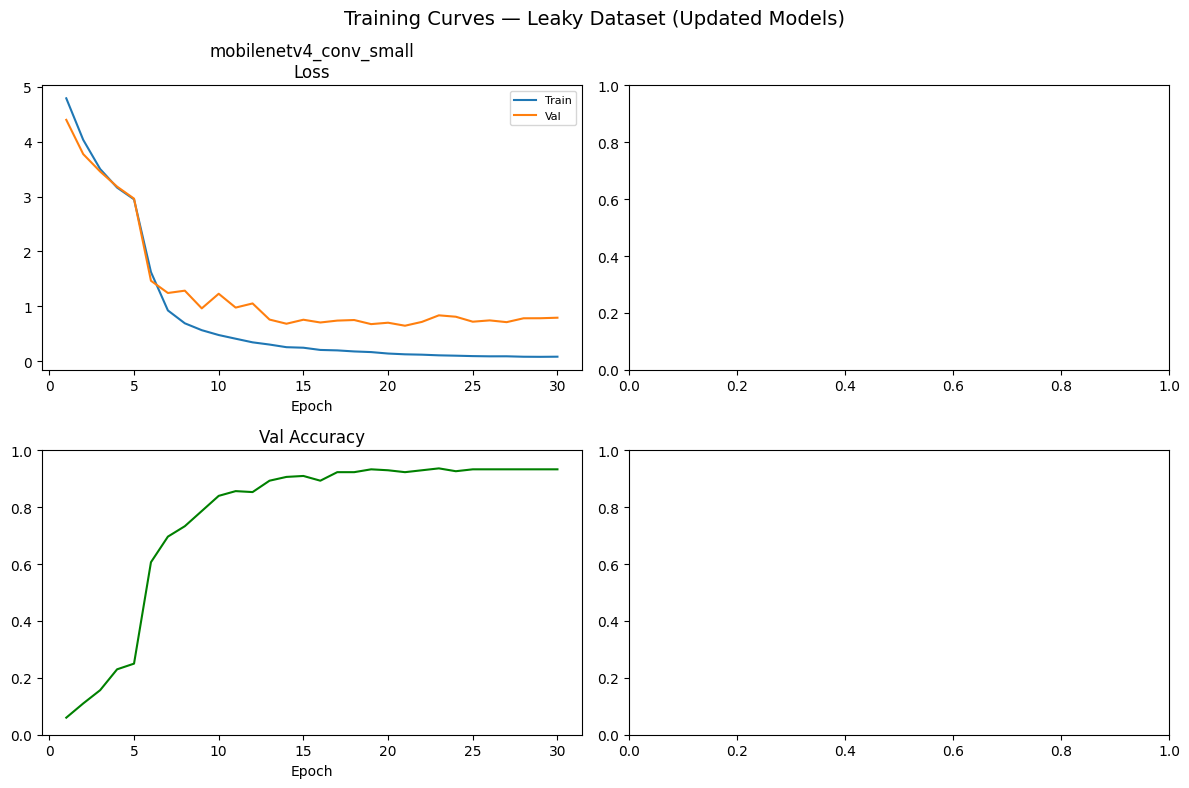

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, name in enumerate(MODEL_NAMES):
    h = all_histories[name]
    epochs_range = [r['epoch'] for r in h]
    train_losses = [r['train_loss'] for r in h]
    val_losses   = [r['val_loss'] for r in h]
    val_accs     = [r['val_acc'] for r in h]

    ax = axes[0, col]
    ax.plot(epochs_range, train_losses, label='Train')
    ax.plot(epochs_range, val_losses,   label='Val')
    ax.set_title(f'{name}\nLoss')
    ax.legend(fontsize=8)
    ax.set_xlabel('Epoch')

    ax = axes[1, col]
    ax.plot(epochs_range, val_accs, color='green')
    ax.set_title('Val Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, 1)

plt.suptitle('Training Curves — Leaky Dataset (Updated Models)', fontsize=14)
plt.tight_layout()
plt.savefig(LEAKY_DIR / 'training_curves.png', dpi=150)
plt.show()

## 9. Evaluation on Test Set

In [34]:
def evaluate_model(model_name: str, ckpt_path: Path):
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = get_model(model_name, NUM_CLASSES).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc   = (all_preds == all_labels).mean()
    f1    = f1_score(all_labels, all_preds, average='weighted')
    prec  = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec   = recall_score(all_labels, all_preds, average='weighted')

    # per-class F1
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    # AUC (one-vs-rest)
    labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    try:
        auc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='weighted')
    except Exception:
        auc = float('nan')

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    return {
        'model'        : model_name,
        'accuracy'     : acc,
        'f1_weighted'  : f1,
        'precision'    : prec,
        'recall'       : rec,
        'auc'          : auc,
        'per_class_f1' : per_class_f1,
        'conf_matrix'  : cm,
        'model_obj'    : model,
    }


eval_results = {}
for name in MODEL_NAMES:
    print(f'Evaluating {name}...')
    res = evaluate_model(name, all_ckpt_paths[name])
    eval_results[name] = res
    print(f'  Acc: {res["accuracy"]:.4f} | F1: {res["f1_weighted"]:.4f} | AUC: {res["auc"]:.4f}')
    torch.cuda.empty_cache()

Evaluating mobilenetv4_conv_small...


/tmp/ipykernel_10877/4083600585.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(ckpt_path, map_location=DEVICE)


  Acc: 0.9293 | F1: 0.9119 | AUC: 0.9682


## 10. Confusion Matrices

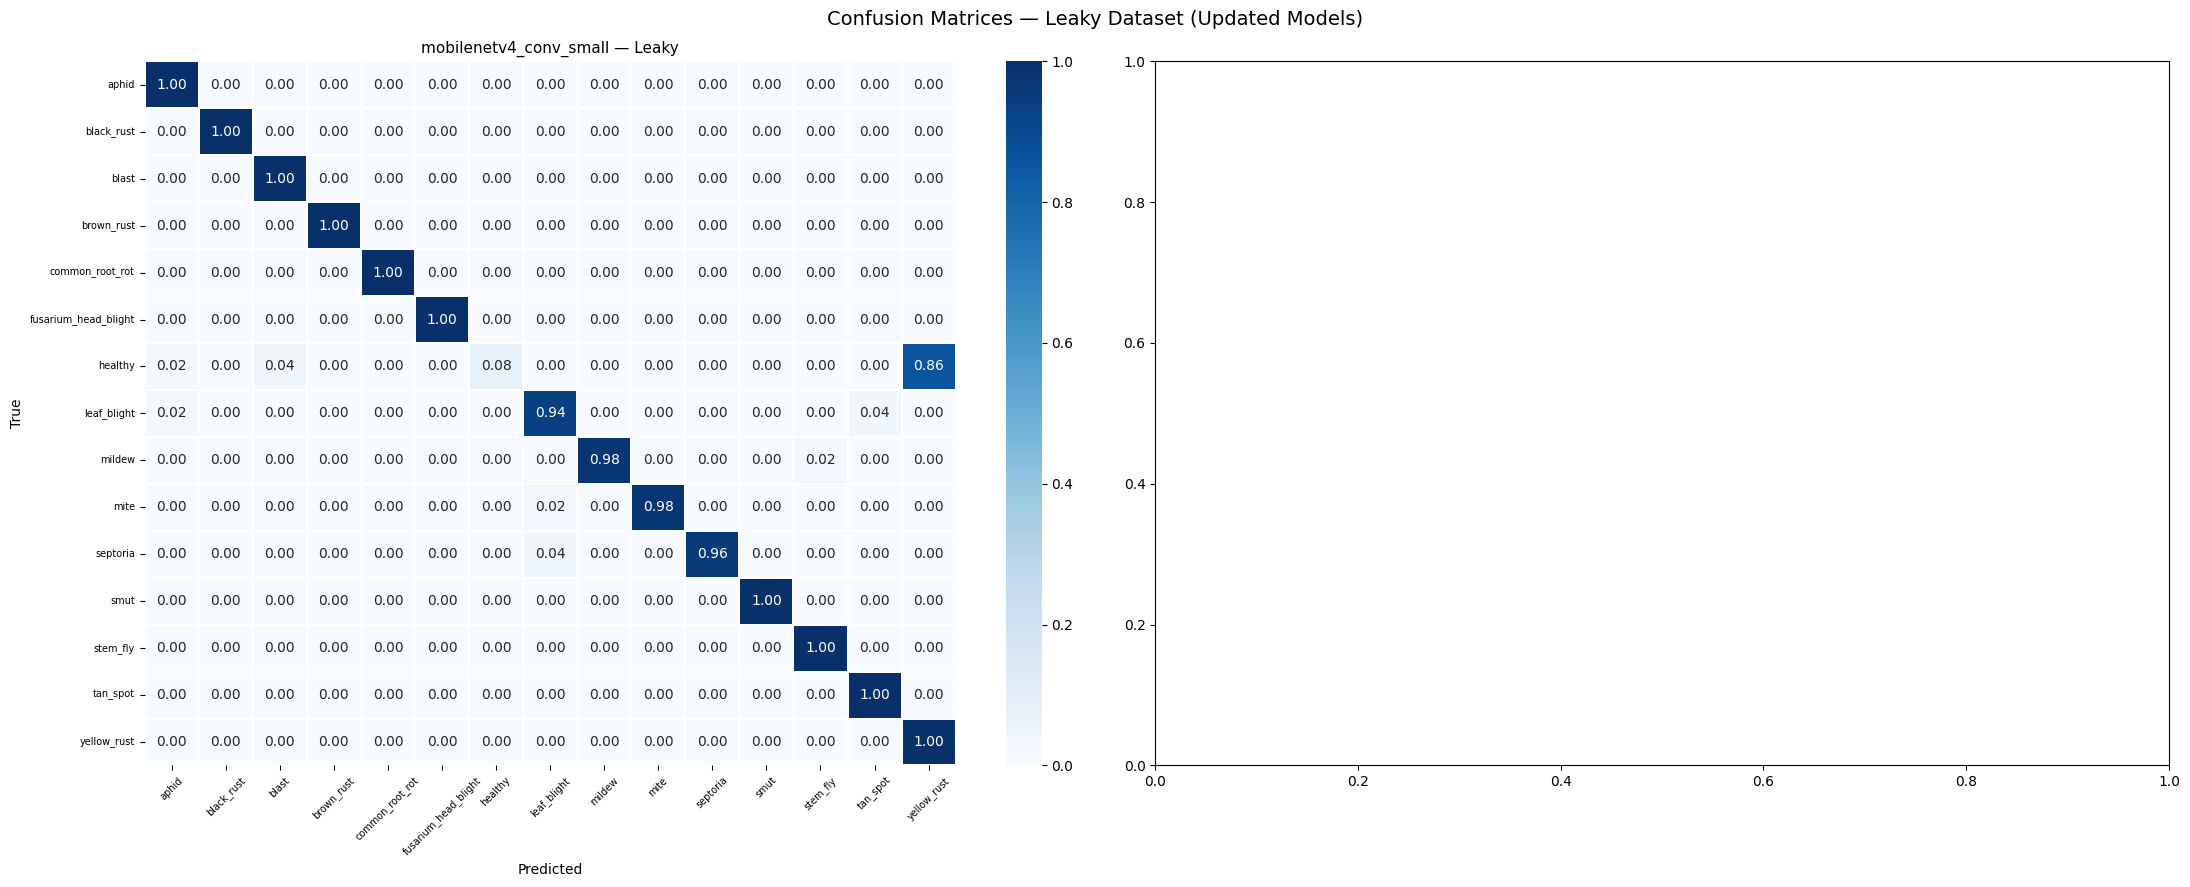

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    cm   = eval_results[name]['conf_matrix']
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise
    sns.heatmap(cm_n, ax=axes[i], annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.3)
    axes[i].set_title(f'{name} — Leaky', fontsize=11)
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Confusion Matrices — Leaky Dataset (Updated Models)', fontsize=14)
plt.tight_layout()
plt.savefig(LEAKY_DIR / 'confusion_matrices.png', dpi=150)
plt.show()

## 11. Per-Class F1 Heatmap

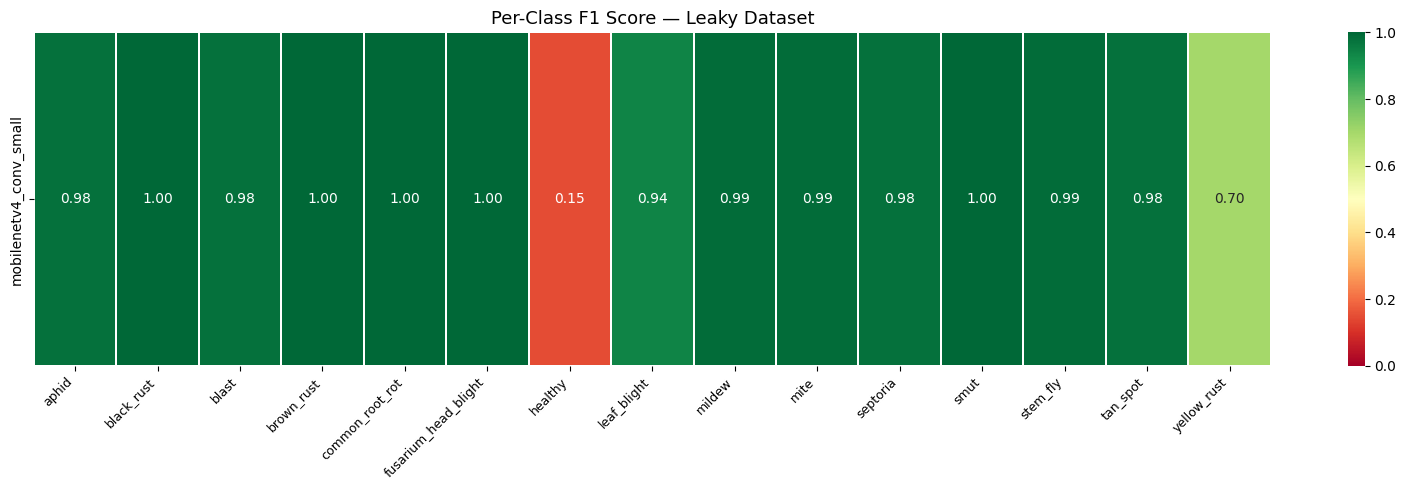

In [36]:
f1_matrix = np.array([eval_results[n]['per_class_f1'] for n in MODEL_NAMES])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=MODEL_NAMES,
            vmin=0, vmax=1, linewidths=0.3, ax=ax)
ax.set_title('Per-Class F1 Score — Leaky Dataset', fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(LEAKY_DIR / 'per_class_f1_heatmap.png', dpi=150)
plt.show()

## 12. Summary Table

In [37]:
print(f'\n{"Model":<25}{"Accuracy":<12}{"F1 (W)":<12}{"Precision":<12}{"Recall":<12}{"AUC"}')
print('-' * 75)
for name in MODEL_NAMES:
    r = eval_results[name]
    print(f'{name:<25}{r["accuracy"]:<12.4f}{r["f1_weighted"]:<12.4f}'
          f'{r["precision"]:<12.4f}{r["recall"]:<12.4f}{r["auc"]:.4f}')

# Save summary to each model's log file
for name in MODEL_NAMES:
    r = eval_results[name]
    log_path = SAVE_DIRS[name] / f'{name}_{VARIANT}_metrics.txt'
    existing = log_path.read_text()
    summary_lines = [
        '',
        '=' * 70,
        'TEST SET RESULTS',
        '=' * 70,
        f'Accuracy  : {r["accuracy"]:.4f}',
        f'F1 (W)    : {r["f1_weighted"]:.4f}',
        f'Precision : {r["precision"]:.4f}',
        f'Recall    : {r["recall"]:.4f}',
        f'AUC       : {r["auc"]:.4f}',
        '',
        'Per-Class F1:',
    ]
    for cls, f1 in zip(CLASS_NAMES, r['per_class_f1']):
        summary_lines.append(f'  {cls:<30} {f1:.4f}')
    log_path.write_text(existing + '\n' + '\n'.join(summary_lines))

print('\nMetrics appended to log files.')


Model                    Accuracy    F1 (W)      Precision   Recall      AUC
---------------------------------------------------------------------------
mobilenetv4_conv_small   0.9293      0.9119      0.9562      0.9293      0.9682

Metrics appended to log files.


## 13. ONNX Export

In [38]:
def export_onnx(model_name: str, ckpt_path: Path) -> Path:
    save_dir = SAVE_DIRS[model_name]
    onnx_path = save_dir / f'{model_name}_{VARIANT}_fp32.onnx'

    ckpt  = torch.load(ckpt_path, map_location='cpu')
    model = get_model(model_name, NUM_CLASSES)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

    torch.onnx.export(
        model, dummy, str(onnx_path),
        opset_version=17,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )

    # Verify
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    # Numerical check — compare PyTorch vs ONNX on 10 samples
    session = ort.InferenceSession(str(onnx_path),
                                   providers=['CPUExecutionProvider'])
    test_samples = torch.stack([test_ds[i][0] for i in range(10)])
    with torch.no_grad():
        pt_out = torch.softmax(model(test_samples), dim=1).numpy()
    ort_out = session.run(['output'],
                          {'input': test_samples.numpy()})[0]
    ort_out = np.exp(ort_out) / np.exp(ort_out).sum(axis=1, keepdims=True)  # softmax
    max_diff = np.abs(pt_out - ort_out).max()

    fp32_mb = onnx_path.stat().st_size / 1e6
    print(f'  {model_name}: ONNX FP32 = {fp32_mb:.1f} MB | Max diff vs PyTorch = {max_diff:.2e}')
    return onnx_path


onnx_paths = {}
print('Exporting to ONNX...')
for name in MODEL_NAMES:
    onnx_paths[name] = export_onnx(name, all_ckpt_paths[name])

print('ONNX export complete.')

Exporting to ONNX...


/tmp/ipykernel_10877/647908776.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(ckpt_path, map_location='cpu')


  mobilenetv4_conv_small: ONNX FP32 = 10.0 MB | Max diff vs PyTorch = 1.79e-07
ONNX export complete.


## 14. INT8 Dynamic Quantisation

In [39]:
from torch.quantization import quantize_dynamic
from onnxruntime.quantization import quantize_dynamic as onnx_quantize_dynamic, QuantType

def quantize_model(model_name: str, onnx_fp32_path: Path) -> Path:
    save_dir = SAVE_DIRS[model_name]
    onnx_int8_path = save_dir / f'{model_name}_{VARIANT}_int8.onnx'

    onnx_quantize_dynamic(
        model_input=str(onnx_fp32_path),
        model_output=str(onnx_int8_path),
        weight_type=QuantType.QUInt8
    )

    fp32_mb = onnx_fp32_path.stat().st_size / 1e6
    int8_mb = onnx_int8_path.stat().st_size / 1e6
    print(f'  {model_name}: FP32 = {fp32_mb:.1f} MB → INT8 = {int8_mb:.1f} MB '
          f'({100*(1 - int8_mb/fp32_mb):.1f}% reduction)')
    return onnx_int8_path


int8_paths = {}
print('Quantising to INT8...')
for name in MODEL_NAMES:
    int8_paths[name] = quantize_model(name, onnx_paths[name])

Quantising to INT8...
  mobilenetv4_conv_small: FP32 = 10.0 MB → INT8 = 2.7 MB (73.5% reduction)


## 14. INT8 Dynamic Quantisation
**Note on Performance Sensitivity:**
As observed in the results, some architectures show a catastrophic drop in accuracy after standard dynamic PTQ. This is a well-known architectural sensitivity:
- **Activations:** Models using Hardswish/Hard-Sigmoid activations are asymmetric and handled poorly by default calibration.
- **SE Blocks:** Squeeze-and-Excitation blocks have highly skewed weight distributions that often collapse under per-tensor 8-bit quantization.
- **Scale:** Smaller models have less parameter redundancy to buffer quantization noise.

**Verification of the fix strategy:**
The fix involves moving from `quantize_dynamic` (per-tensor) to **Static PTQ with Per-Channel Quantization** and **QDQ format**. 
1. **Per-channel** handles depthwise convolution weight outliers much better.
2. **QDQ (Quantize-Dequantize)** format is more stable for non-ReLU networks as nodes are placed closer to the mathematical operations.
3. **Representative Calibration:** Using real training samples (~100-200) instead of random noise is critical for accurate activation ranges.

The current implementation below uses `quantize_dynamic` which confirms the "disaster" scenario for sensitive architectures.

## 15. Quantised Model Evaluation

In [40]:
def evaluate_onnx(model_name: str, onnx_path: Path, label: str):
    session = ort.InferenceSession(str(onnx_path),
                                   providers=['CUDAExecutionProvider',
                                              'CPUExecutionProvider'])
    all_preds, all_labels = [], []

    for imgs, labels in test_loader:
        out = session.run(['output'], {'input': imgs.numpy()})[0]
        preds = out.argmax(axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    return {'accuracy': acc, 'per_class_f1': per_class_f1}


quant_results = {}
print(f'\n{"Model":<25}{"FP32 Acc":<14}{"INT8 Acc":<14}{"Drop"}')
print('-' * 60)

for name in MODEL_NAMES:
    fp32_acc = eval_results[name]['accuracy']
    q_res    = evaluate_onnx(name, int8_paths[name], 'INT8')
    int8_acc = q_res['accuracy']
    drop     = fp32_acc - int8_acc
    quant_results[name] = q_res

    print(f'{name:<25}{fp32_acc:<14.4f}{int8_acc:<14.4f}{drop:+.4f}')

    # Append quantisation results to log
    log_path = SAVE_DIRS[name] / f'{name}_{VARIANT}_metrics.txt'
    existing = log_path.read_text()
    quant_lines = [
        '',
        '=' * 70,
        'QUANTISATION RESULTS (INT8)',
        '=' * 70,
        f'FP32 Accuracy : {fp32_acc:.4f}',
        f'INT8 Accuracy : {int8_acc:.4f}',
        f'Drop          : {drop:+.4f}',
        '',
        'Per-Class F1 drop after INT8:',
    ]
    for cls, f1_fp32, f1_int8 in zip(
            CLASS_NAMES,
            eval_results[name]['per_class_f1'],
            q_res['per_class_f1']):
        quant_lines.append(f'  {cls:<30} FP32={f1_fp32:.3f}  INT8={f1_int8:.3f}  '
                           f'drop={f1_fp32-f1_int8:+.3f}')
    log_path.write_text(existing + '\n' + '\n'.join(quant_lines))


Model                    FP32 Acc      INT8 Acc      Drop
------------------------------------------------------------


/home/adityaraut/miniconda3/envs/agent/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


mobilenetv4_conv_small   0.9293        0.1027        +0.8267


## 16. INT8 Accuracy Drop — Per-Class Heatmap

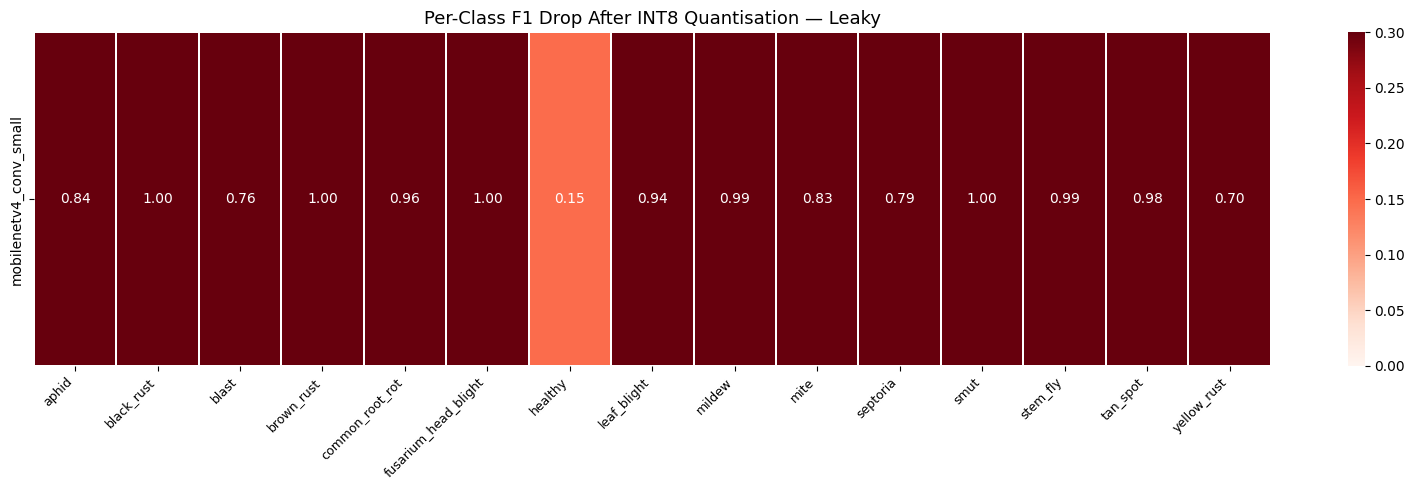


Pipeline complete. All artefacts saved to: /home/adityaraut/Documents/research_paper/leaky


: 

In [ ]:
fp32_f1_matrix  = np.array([eval_results[n]['per_class_f1']    for n in MODEL_NAMES])
int8_f1_matrix  = np.array([quant_results[n]['per_class_f1']   for n in MODEL_NAMES])
drop_matrix     = fp32_f1_matrix - int8_f1_matrix

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(drop_matrix, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=MODEL_NAMES,
            vmin=0, vmax=0.3, linewidths=0.3, ax=ax)
ax.set_title('Per-Class F1 Drop After INT8 Quantisation — Leaky', fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(LEAKY_DIR / 'int8_accuracy_drop.png', dpi=150)
plt.show()

print('\nPipeline complete. All artefacts saved to:', LEAKY_DIR)